# Stage 5: Exploratory Data Analysis & Business Hypothesis Testing

## Objective & Roadmap
The primary objective of Stage 5 is to transition from data audit to behavioral exploration. 
We validate key business assumptions, evaluate distributions, and test empirical hypotheses regarding customer satisfaction, logistics bottlenecks, and revenue drivers.

### Step 5.1: Environment Setup, Relational Ingestion & Category Translation
**Purpose:** Initialize the analytical environment with data visualization libraries (`matplotlib`, `seaborn`), ingest the raw tables, parse essential temporal timestamps, and enrich the product catalog with English taxonomy translations.

# Stage 5: Exploratory Data Analysis & Business Hypothesis Testing

## Step 5.1: Initial Data Ingestion
**Purpose:** Load the core tables required for exploratory analysis.

In [59]:
import pandas as pd
from pathlib import Path

RAW_PATH = Path("../data/raw")

# Load tables for analysis
df_orders = pd.read_csv(RAW_PATH / "olist_orders_dataset.csv")
df_customers = pd.read_csv(RAW_PATH / "olist_customers_dataset.csv")
df_items = pd.read_csv(RAW_PATH / "olist_order_items_dataset.csv")
df_payments = pd.read_csv(RAW_PATH / "olist_order_payments_dataset.csv")
df_reviews = pd.read_csv(RAW_PATH / "olist_order_reviews_dataset.csv")
df_products = pd.read_csv(RAW_PATH / "olist_products_dataset.csv")
df_translations = pd.read_csv(RAW_PATH / "product_category_name_translation.csv")
df_sellers =  pd.read_csv(RAW_PATH / "olist_sellers_dataset.csv")

print("Files loaded into memory.")

Files loaded into memory.


## Step 5.2: Product Category Name Translation
**Purpose:** Merge Portuguese category tags with their English counterparts from the translation reference table.

In [60]:
# Left join to append english category names
df_products = df_products.merge(df_translations, on="product_category_name", how="left")

# Check sample result
df_products[["product_id", "product_category_name", "product_category_name_english"]].head()
# print(df_products.head().to_string())

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


## Step 5.3: Translation Missingness Check
**Purpose:** Check if any product category failed to map to an English equivalent.

In [61]:
# Check how many categories remain unmapped
unmapped_count = df_products["product_category_name_english"].isnull().sum()
print(f"Products with missing English category: {unmapped_count}")

# Fill unmapped/null categories with a clear label
df_products["product_category_name_english"] = df_products["product_category_name_english"].fillna("uncategorized")

Products with missing English category: 623


## Step 5.4: Product Category Sales & Revenue Analysis
**Purpose:** Aggregate sales volume and gross revenue across product categories to identify key business drivers.

In [62]:
# Merge order items with products to bring in english category names
df_items_prod = df_items.merge(
    df_products[["product_id", "product_category_name_english"]], 
    on="product_id", 
    how="left"
)

# Aggregate total items sold and total revenue per category
category_summary = df_items_prod.groupby("product_category_name_english").agg(
    total_orders_sold=("order_item_id", "count"),
    total_revenue=("price", "sum"),
    avg_item_price=("price", "mean")
).reset_index()

# Sort by revenue descending
top_revenue_categories = category_summary.sort_values(by="total_revenue", ascending=False).head(10)
top_revenue_categories["total_revenue"] = top_revenue_categories["total_revenue"].round(1)
top_revenue_categories["avg_item_price"] = top_revenue_categories["avg_item_price"].round(2)

display(top_revenue_categories)

,product_category_name_english,total_orders_sold,total_revenue,avg_item_price
43,health_beauty,9670,1258681.3,130.16
71,watches_gifts,5991,1205005.7,201.14
7,bed_bath_table,11115,1036988.7,93.30
65,sports_leisure,8641,988049.0,114.34
15,computers_accessories,7827,911954.3,116.51
39,furniture_decor,8334,729762.5,87.56
20,cool_stuff,3796,635290.8,167.36
49,housewares,6964,632248.7,90.79
5,auto,4235,592720.1,139.96
42,garden_tools,4347,485256.5,111.63


## Step 5.5: Visualizing Top 10 Product Categories by Revenue and Volume
**Purpose:** Plot horizontal bar charts comparing gross revenue and order item volume across the top 10 categories to visualize business concentration.

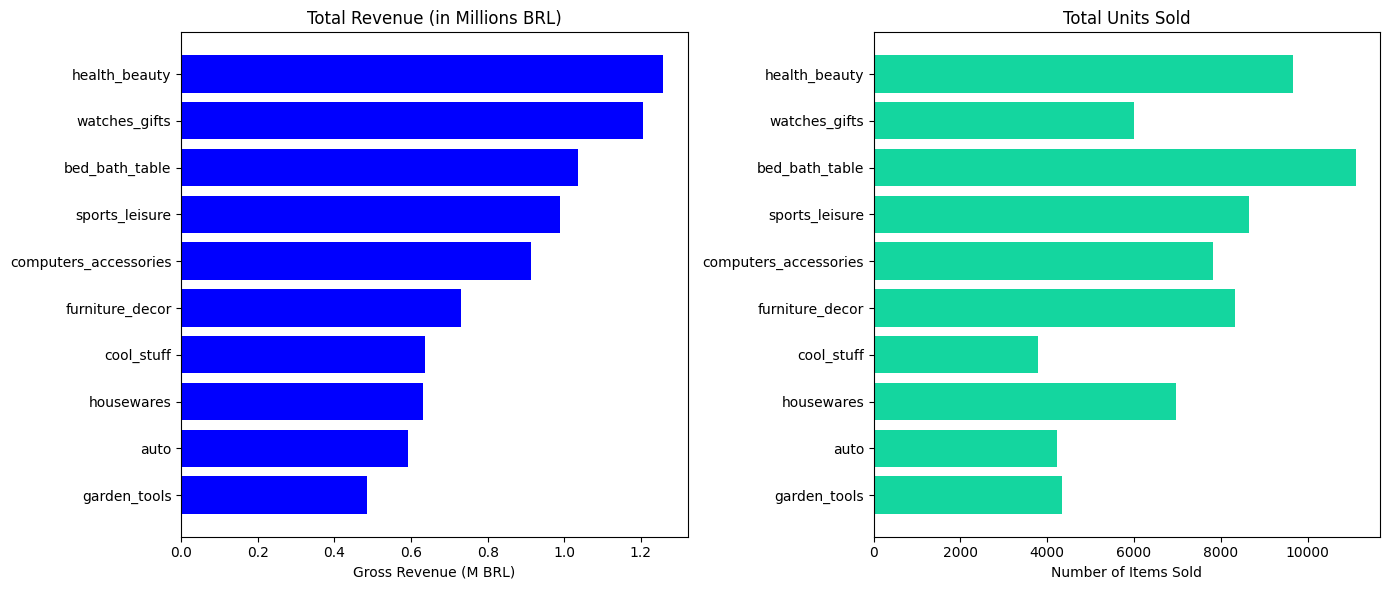

In [63]:
import matplotlib.pyplot as plt

# Prepare data sorted ascending for horizontal bar chart display
plot_data = top_revenue_categories.sort_values(by="total_revenue", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# 1. Total Revenue Plot
axes[0].barh(plot_data["product_category_name_english"], plot_data["total_revenue"] / 1e6, color="blue")
axes[0].set_title("Total Revenue (in Millions BRL)")
axes[0].set_xlabel("Gross Revenue (M BRL)")

# 2. Total Orders Sold (Volume) Plot
axes[1].barh(plot_data["product_category_name_english"], plot_data["total_orders_sold"], color="#14d69f")
axes[1].set_title("Total Units Sold")
axes[1].set_xlabel("Number of Items Sold")

plt.tight_layout()
plt.show()

## Step 5.6: Customer Geographic Distribution & State Concentration
**Purpose:** Quantify the geographic spread of unique customers across Brazilian states to evaluate geographic dependency and market concentration.

In [64]:
# Calculate customer counts and percentage share by state
state_counts = df_customers["customer_state"].value_counts().reset_index()
state_counts.columns = ["state", "customer_count"]
state_counts["percentage_share"] = ((state_counts["customer_count"] / len(df_customers)) * 100).round(2)

# Top 10 States by Customer Volume
top_10_states = state_counts.head(10)
display(top_10_states)

,state,customer_count,percentage_share
0,SP,41746,41.98
1,RJ,12852,12.92
2,MG,11635,11.70
3,RS,5466,5.50
4,PR,5045,5.07
5,SC,3637,3.66
6,BA,3380,3.40
7,DF,2140,2.15
8,ES,2033,2.04
9,GO,2020,2.03


## Step 5.7: Visualizing Top 10 Customer Concentration States
**Purpose:** Plot a Pareto-style horizontal bar chart to demonstrate state-level customer concentration.

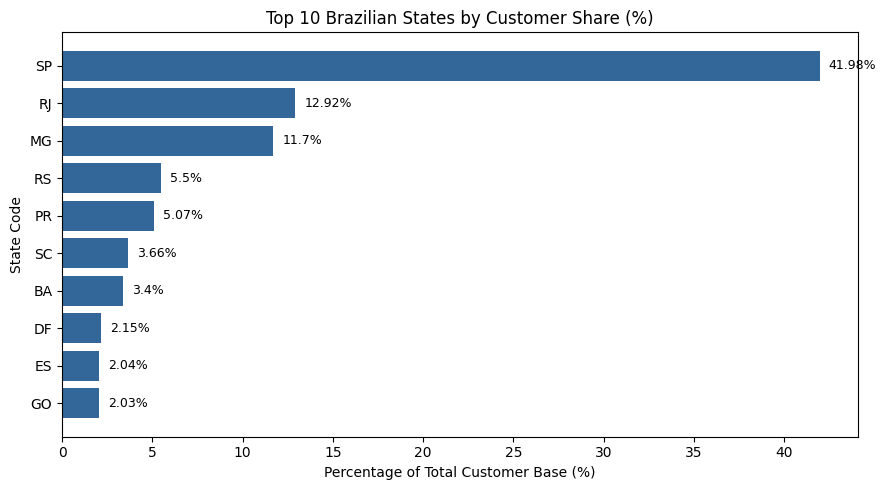

In [65]:
fig, ax = plt.subplots(figsize=(9, 5))

# Plot top 10 states
ax.barh(top_10_states["state"][::-1], top_10_states["percentage_share"][::-1], color="#336699")
ax.set_title("Top 10 Brazilian States by Customer Share (%)")
ax.set_xlabel("Percentage of Total Customer Base (%)")
ax.set_ylabel("State Code")

# Annotate bars with percentage values
for index, value in enumerate(top_10_states["percentage_share"][::-1]):
    ax.text(value + 0.5, index, f"{value}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Step 5.8: Payment Method Preferences & Financial Distribution
**Purpose:** Analyze customer payment preferences across payment types (credit card, boleto, voucher, debit card) and inspect installment behaviors.

In [66]:
# payment type distribution 

payment_dist = df_payments["payment_type"].value_counts().reset_index()
payment_dist.columns = ["payment_type", "transaction_count"]
payment_dist["payment_share"] = ((payment_dist["transaction_count"]/len(df_payments))*100).round(2)

# average payment value per payment type
avg_payment_type = df_payments.groupby("payment_type")["payment_value"].mean().reset_index()
avg_payment_type.columns = ["payment_type", 'avg_payment_value']

# merge summary 
payment_summary = payment_dist.merge(avg_payment_type , on="payment_type")
print(payment_summary)

  payment_type  transaction_count  payment_share  avg_payment_value
0  credit_card              76795          73.92         163.319021
1       boleto              19784          19.04         145.034435
2      voucher               5775           5.56          65.703354
3   debit_card               1529           1.47         142.570170
4  not_defined                  3           0.00           0.000000


<function matplotlib.pyplot.show(close=None, block=None)>

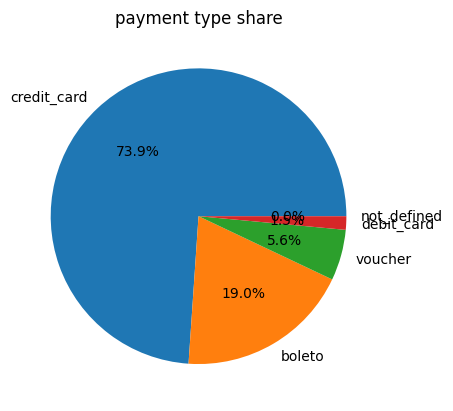

In [67]:
# pie chart 

plt.Figure(figsize=(10,8))
plt.pie(
    payment_dist["transaction_count"],
    labels= payment_dist["payment_type"],
    autopct= "%1.1f%%"
)
plt.title("payment type share")
plt.show

## Step 5.9: Credit Card Installment Distribution
**Purpose:** Explore how customers utilize credit card installment facilities to distribute order costs over time.

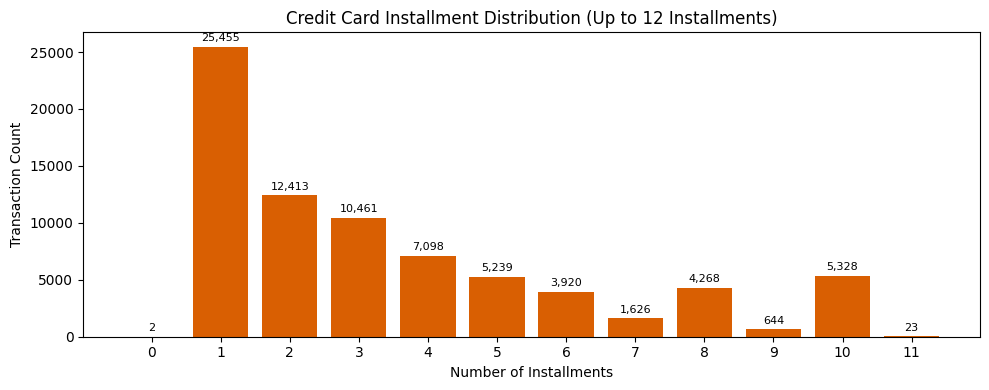

In [68]:
# Filter only credit card transactions to observe installment spread
credit_df = df_payments[df_payments["payment_type"] == "credit_card"]

fig, ax = plt.subplots(figsize=(10, 4))
installment_counts = credit_df["payment_installments"].value_counts().sort_index().head(12)

ax.bar(installment_counts.index.astype(str), installment_counts.values, color="#d95f02")
ax.set_title("Credit Card Installment Distribution (Up to 12 Installments)")
ax.set_xlabel("Number of Installments")
ax.set_ylabel("Transaction Count")

for idx, val in enumerate(installment_counts.values):
    ax.text(idx, val + 500, f"{val:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## Step 5.10: Delivery Performance & Customer Satisfaction Linkage
**Purpose:** Quantify the impact of logistics SLA breaches (late deliveries) on customer review scores by computing on-time vs late satisfaction divergence.

In [69]:
# Convert order dates to datetime if not already parsed
date_fields = ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in date_fields:
    df_orders[col] = pd.to_datetime(df_orders[col], errors="coerce")

# Filter only successfully delivered orders
delivered_orders = df_orders[df_orders["order_status"] == "delivered"].copy()

# Calculate delivery duration (days taken) and delivery delay (days late compared to estimate)
delivered_orders["delivery_days"] = (delivered_orders["order_delivered_customer_date"] - delivered_orders["order_purchase_timestamp"]).dt.days
delivered_orders["delay_days"] = (delivered_orders["order_delivered_customer_date"] - delivered_orders["order_estimated_delivery_date"]).dt.days

# Binary SLA flag: 1 if delivered after estimated date, 0 otherwise
delivered_orders["is_late"] = delivered_orders["delay_days"] > 0

# Merge with reviews to map review scores
order_reviews_merged = delivered_orders.merge(
    df_reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

# Aggregate satisfaction by delivery status
sla_satisfaction = order_reviews_merged.groupby("is_late").agg(
    order_count=("order_id", "count"),
    mean_review_score=("review_score", "mean"),
    five_star_pct=("review_score", lambda x: round((x == 5).mean() * 100, 2)),
    one_star_pct=("review_score", lambda x: round((x == 1).mean() * 100, 2))
).reset_index()

sla_satisfaction["is_late"] = sla_satisfaction["is_late"].map({False: "On Time / Early", True: "Late (SLA Breach)"})
sla_satisfaction["mean_review_score"] = sla_satisfaction["mean_review_score"].round(2)

display(sla_satisfaction)

,is_late,order_count,mean_review_score,five_star_pct,one_star_pct
0,On Time / Early,89952,4.29,62.26,6.63
1,Late (SLA Breach),6409,2.27,16.54,53.74


## Step 5.11: Visualizing Satisfaction Gap by Delivery SLA
**Purpose:** Plot a side-by-side bar chart showing the difference in 1-star complaints and 5-star ratings between on-time and late orders.

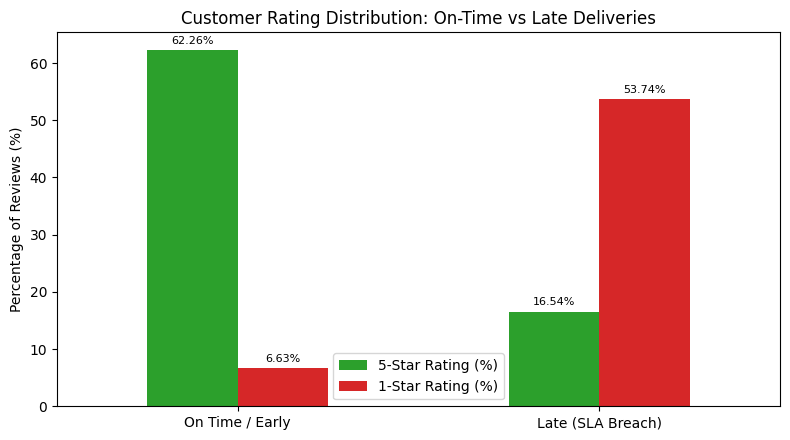

In [70]:
# sla_satisfaction ko plot ke liye set karein
plot_df = sla_satisfaction.set_index("is_late")[["five_star_pct", "one_star_pct"]]

# Direct Pandas bar plot
ax = plot_df.plot(kind="bar", figsize=(8, 4.5), color=["#2ca02c", "#d62728"], rot=0)

plt.title("Customer Rating Distribution: On-Time vs Late Deliveries")
plt.ylabel("Percentage of Reviews (%)")
plt.xlabel("")
plt.legend(["5-Star Rating (%)", "1-Star Rating (%)"])

# Ek hi line me sabhi bars par label aa jayenge (No loop math needed)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

## Step 5.12: Logistics Friction & Cross-State Order Analysis
**Purpose:** Quantify the impact of geographic boundaries (intra-state vs cross-state shipping) on freight costs and customer delivery turnaround time.

In [71]:
# 1. Items aur Orders ko jodein
df_logistics = df_items[["order_id", "seller_id", "freight_value"]].merge(
    df_orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp", "order_delivered_customer_date"]],
    on="order_id"
)

# 2. Customer state jodein
df_logistics = df_logistics.merge(
    df_customers[["customer_id", "customer_state"]], 
    on="customer_id"
)

# 3. Seller state jodein
df_logistics = df_logistics.merge(
    df_sellers[["seller_id","seller_state"]], 
    on="seller_id"
)

# Sirf successfully delivered orders rakhein
df_logistics = df_logistics[df_logistics["order_status"] == "delivered"].copy()

df_logistics[["customer_state", "seller_state", "freight_value"]].head(3)

,customer_state,seller_state,freight_value
0,RJ,SP,13.29
1,SP,SP,19.93
2,MG,MG,17.87


In [72]:
# Delivery duration (in days)
df_logistics["delivery_days"] = (
    pd.to_datetime(df_logistics["order_delivered_customer_date"]) - 
    pd.to_datetime(df_logistics["order_purchase_timestamp"])
).dt.days

# Check karein kya seller aur customer same state me hain
df_logistics["is_same_state"] = df_logistics["customer_state"] == df_logistics["seller_state"]

df_logistics[["customer_state", "seller_state", "is_same_state", "delivery_days"]].head(3)

,customer_state,seller_state,is_same_state,delivery_days
0,RJ,SP,False,7.0
1,SP,SP,True,16.0
2,MG,MG,True,7.0


In [73]:
# Group by same state vs cross state
logistics_summary = df_logistics.groupby("is_same_state").agg(
    order_item_count=("order_id", "count"),
    avg_freight_value=("freight_value", "mean"),
    avg_delivery_days=("delivery_days", "mean")
).reset_index()

# Readable labels lagayein
logistics_summary["shipping_type"] = logistics_summary["is_same_state"].map({
    True: "Intra-State (Same State)", 
    False: "Inter-State (Cross-State)"
})

logistics_summary["avg_freight_value"] = logistics_summary["avg_freight_value"].round(2)
logistics_summary["avg_delivery_days"] = logistics_summary["avg_delivery_days"].round(1)

# Display final comparison table
display(logistics_summary[["shipping_type", "order_item_count", "avg_freight_value", "avg_delivery_days"]])

,shipping_type,order_item_count,avg_freight_value,avg_delivery_days
0,Inter-State (Cross-State),70331,23.63,14.6
1,Intra-State (Same State),39866,13.45,7.5


## Step 5.13: Customer Retention & Repeat Purchase Exploration
**Purpose:** Quantify the frequency of repeat transactions per unique customer to evaluate platform stickiness versus churn.

In [74]:
# total order count of per unique customer.

customer_order_counts = (
    df_customers.groupby("customer_unique_id")["customer_id"].count().value_counts().reset_index()

)

customer_order_counts.columns = ["orders_placed", "customer_count"]
customer_order_counts.head(5)



,orders_placed,customer_count
0,1,93099
1,2,2745
2,3,203
3,4,30
4,5,8


In [75]:
# Total customers
total_unique = customer_order_counts["customer_count"].sum()

# 1 order wale vs 2 ya usse zyada wale
one_time_buyers = customer_order_counts.loc[customer_order_counts["orders_placed"] == 1, "customer_count"].values[0]
repeat_buyers = customer_order_counts.loc[customer_order_counts["orders_placed"] > 1, "customer_count"].sum()

retention_summary = pd.DataFrame([
    {"Customer Type": "One-Time Buyers (1 Order)", "Count": one_time_buyers, "Share (%)": round((one_time_buyers / total_unique) * 100, 2)},
    {"Customer Type": "Repeat Buyers (2+ Orders)", "Count": repeat_buyers, "Share (%)": round((repeat_buyers / total_unique) * 100, 2)}
])

display(retention_summary)

,Customer Type,Count,Share (%)
0,One-Time Buyers (1 Order),93099,96.88
1,Repeat Buyers (2+ Orders),2997,3.12


## Step 5.14: Monthly Order Volume & Seasonality Trends
**Purpose:** Track monthly order volume across the dataset timeline to evaluate platform growth patterns and festive demand surges.

In [76]:
# Purchase timestamp se Year-Month period nikaalte hain
df_orders["order_purchase_timestamp"] = pd.to_datetime(df_orders["order_purchase_timestamp"])
df_orders["order_purchase_year_month"] = df_orders["order_purchase_timestamp"].dt.to_period("M")

# Monthly order volume count karein
monthly_orders = df_orders.groupby("order_purchase_year_month")["order_id"].count().reset_index()
monthly_orders.columns = ["year_month", "order_count"]

# Convert period to string for plotting
monthly_orders["year_month"] = monthly_orders["year_month"].astype(str)

monthly_orders.tail(6)

,year_month,order_count
19,2018-05,6873
20,2018-06,6167
21,2018-07,6292
22,2018-08,6512
23,2018-09,16
24,2018-10,4


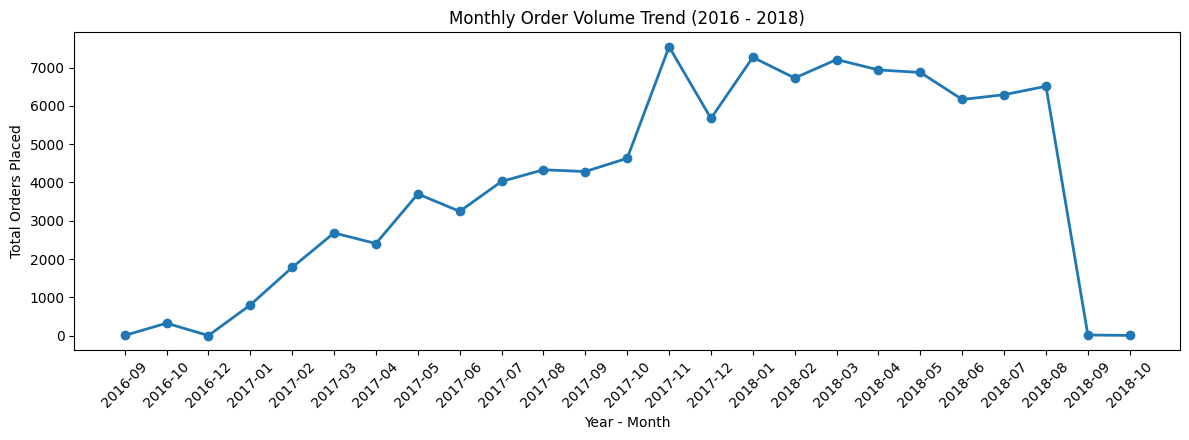

In [77]:
fig, ax = plt.subplots(figsize=(12, 4.5))

# Plot simple line chart
ax.plot(monthly_orders["year_month"], monthly_orders["order_count"], marker="o", color="#1f77b4", linewidth=2)

ax.set_title("Monthly Order Volume Trend (2016 - 2018)")
ax.set_xlabel("Year - Month")
ax.set_ylabel("Total Orders Placed")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Step 5.15: Freight-to-Price Friction & Satisfaction Sensitivity
**Purpose:** Measure the proportion of shipping charges relative to item price (freight ratio) and evaluate whether excessive logistics surcharges depress customer review scores.

In [78]:
# calculate the freight ratio 

df_freight_ratio = df_items.groupby("order_id").agg(
    total_price =("price", "sum"),
    total_freight = ("freight_value", "sum") 
)

df_freight_ratio["freight_ratio"] = (df_freight_ratio["total_freight"]/ df_freight_ratio["total_price"]).round(3)

df_freight_review = df_freight_ratio.merge(
    df_reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

df_freight_review[["total_price", "total_freight", "freight_ratio", "review_score"]].head()

,total_price,total_freight,freight_ratio,review_score
0,58.90,13.29,0.226,5
1,239.90,19.93,0.083,4
2,199.00,17.87,0.090,5
3,12.99,12.79,0.985,4
4,199.90,18.14,0.091,5


In [79]:


# Simple helper function
def categorize_freight(ratio):
    if ratio <= 0.15:
        return "Low (< 15%)"
    elif ratio <= 0.30:
        return "Moderate (15-30%)"
    elif ratio <= 0.50:
        return "High (30-50%)"
    else:
        return "Extreme (> 50%)"

# Direct apply
df_freight_review["freight_burden_level"] = df_freight_review["freight_ratio"].apply(categorize_freight)

# 1-star indicator flag (True / False ko 1 ya 0 banate hain)
df_freight_review["is_one_star"] = (df_freight_review["review_score"] == 1).astype(int)

df_freight_review[["freight_ratio", "freight_burden_level", "review_score", "is_one_star"]].head()

,freight_ratio,freight_burden_level,review_score,is_one_star
0,0.226,Moderate (15-30%),5,0
1,0.083,Low (< 15%),4,0
2,0.090,Low (< 15%),5,0
3,0.985,Extreme (> 50%),4,0
4,0.091,Low (< 15%),5,0


In [80]:
# Groupby karke seedha average aur count nikaalein
freight_impact = df_freight_review.groupby("freight_burden_level").agg(
    orders_count=("order_id", "count"),
    mean_review_score=("review_score", "mean"),
    one_star_rate=("is_one_star", "mean")
).reset_index()

# Percentages aur decimal clean karein
freight_impact["one_star_pct"] = (freight_impact["one_star_rate"] * 100).round(2)
freight_impact["mean_review_score"] = freight_impact["mean_review_score"].round(2)

# Unnecessary column drop karke clean view dikhayein
freight_impact = freight_impact.drop(columns=["one_star_rate"])

display(freight_impact)

,freight_burden_level,orders_count,mean_review_score,one_star_pct
0,Extreme (> 50%),15585,4.06,11.41
1,High (30-50%),18837,4.08,11.46
2,Low (< 15%),29935,4.13,11.15
3,Moderate (15-30%),34108,4.12,10.58


## create the delay buckets

In [81]:
# Helper function jo delay days ko simple labels dega
def check_delay_bucket(row):
    if row["delay_days"] <= 0:
        return "0. On Time or Early"
    elif row["delay_days"] <= 3:
        return "1. Slight Delay (1-3 days)"
    elif row["delay_days"] <= 7:
        return "2. Moderate Delay (4-7 days)"
    else:
        return "3. Severe Delay (> 7 days)"

# Late orders par apply karein
order_reviews_merged["delay_bucket"] = order_reviews_merged.apply(check_delay_bucket, axis=1)

# 1-star review check karne ke liye flag
order_reviews_merged["is_one_star"] = (order_reviews_merged["review_score"] == 1).astype(int)

order_reviews_merged[["delay_days", "delay_bucket", "review_score", "is_one_star"]].head()

,delay_days,delay_bucket,review_score,is_one_star
0,-8.0,0. On Time or Early,4,0
1,-6.0,0. On Time or Early,4,0
2,-18.0,0. On Time or Early,5,0
3,-13.0,0. On Time or Early,5,0
4,-10.0,0. On Time or Early,5,0


In [82]:
# Groupby karke basic average aur count nikaalte hain
delay_summary = order_reviews_merged.groupby("delay_bucket").agg(
    orders_count=("order_id", "count"),
    avg_score=("review_score", "mean"),
    one_star_rate=("is_one_star", "mean")
).reset_index()

# Clean numbers
delay_summary["avg_score"] = delay_summary["avg_score"].round(2)
delay_summary["one_star_pct"] = (delay_summary["one_star_rate"] * 100).round(2)

# Unneeded column drop karein
delay_summary = delay_summary.drop(columns=["one_star_rate"])

display(delay_summary)

,delay_bucket,orders_count,avg_score,one_star_pct
0,0. On Time or Early,89944,4.29,6.63
1,1. Slight Delay (1-3 days),1856,3.29,25.16
2,2. Moderate Delay (4-7 days),1756,2.10,58.54
3,3. Severe Delay (> 7 days),2805,1.71,69.52


## Step 5.17: Customer Review Text Presence vs Review Score
**Purpose:** Evaluate whether the presence of a written review comment signals customer dissatisfaction compared to submitting star ratings alone.

In [83]:
# Check karein ki customer ne text comment likha hai ya blank chhod diya hai
df_reviews["has_comment"] = df_reviews["review_comment_message"].notna().astype(int)

# 1-star indicator flag
df_reviews["is_one_star"] = (df_reviews["review_score"] == 1).astype(int)

df_reviews[["review_score", "has_comment", "is_one_star"]].head()

,review_score,has_comment,is_one_star
0,4,0,0
1,5,0,0
2,5,0,0
3,5,1,0
4,5,1,0


## Step 5.17.1: Aggregating Feedback Sentiment by Comment Presence
**Purpose:** Compute the average rating and 1-star frequency between customers who left text comments versus those who left only star ratings.

In [84]:
# Groupby karke basic average aur count nikaalte hain
comment_summary = df_reviews.groupby("has_comment").agg(
    review_count=("review_id", "count"),
    avg_score=("review_score", "mean"),
    one_star_rate=("is_one_star", "mean")
).reset_index()

# Readable labels aur percentages
comment_summary["feedback_type"] = comment_summary["has_comment"].map({
    0: "No Text (Rating Only)",
    1: "Written Text Comment"
})

comment_summary["avg_score"] = comment_summary["avg_score"].round(2)
comment_summary["one_star_pct"] = (comment_summary["one_star_rate"] * 100).round(2)

# Unneeded columns drop karein
comment_summary = comment_summary[["feedback_type", "review_count", "avg_score", "one_star_pct"]]

display(comment_summary)

,feedback_type,review_count,avg_score,one_star_pct
0,No Text (Rating Only),58256,4.38,4.60
1,Written Text Comment,40968,3.67,21.35


## Step 5.18.2: Aligned Correlation Matrix by Order ID
**Purpose:** Properly join delivery timelines, delays, freight values, and review scores on order_id to compute genuine pairwise correlations.

In [85]:
# 1. Logistics se zaroori columns nikaalein (order level par group karke)
logistics_order_level = df_logistics.groupby("order_id").agg(
    delivery_days=("delivery_days", "mean"),
    freight_value=("freight_value", "sum")
).reset_index()

# 2. Reviews aur delay data ke sath order_id par merge karein
df_corr_aligned = logistics_order_level.merge(
    order_reviews_merged[["order_id", "delay_days", "review_score"]],
    on="order_id",
    how="inner"
)

# 3. Sirf numeric columns rakhein
df_corr_numeric = df_corr_aligned[["delivery_days", "delay_days", "freight_value", "review_score"]].dropna()

df_corr_numeric.head(3)

,delivery_days,delay_days,freight_value,review_score
0,7.0,-9.0,13.29,5
1,16.0,-3.0,19.93,4
2,7.0,-14.0,17.87,5


## Step 5.18.3: Accurate Correlation Matrix Output
**Purpose:** Display the verified Pearson correlation matrix across all aligned order-level variables.

In [86]:
# Sahi correlation matrix calculate karein
correct_correlation = df_corr_numeric.corr().round(2)

# Display karein
display(correct_correlation)

,delivery_days,delay_days,freight_value,review_score
delivery_days,1.00,0.60,0.17,-0.33
delay_days,0.60,1.00,-0.05,-0.27
freight_value,0.17,-0.05,1.00,-0.09
review_score,-0.33,-0.27,-0.09,1.00


In [88]:
output_dir = "../data/interim"

# Saari 8 clean tables ko interim folder mein save karein
df_orders.to_csv(f"{output_dir}/clean_orders.csv", index=False)
df_reviews.to_csv(f"{output_dir}/clean_reviews.csv", index=False)
df_items.to_csv(f"{output_dir}/clean_items.csv", index=False)
df_customers.to_csv(f"{output_dir}/clean_customers.csv", index=False)
df_sellers.to_csv(f"{output_dir}/clean_sellers.csv", index=False)
df_payments.to_csv(f"{output_dir}/clean_payments.csv", index=False)
df_products.to_csv(f"{output_dir}/clean_products.csv", index=False)


print("Poori 8 clean datasets successfully save ho gayi hain '../data/interim' mein!")

Poori 8 clean datasets successfully save ho gayi hain '../data/interim' mein!
